## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_excel('dataset.xlsx')
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


# Data Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [5]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [6]:
df[df['Customer ID'].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [7]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [8]:
df[df['Quantity']<0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [9]:
df[df['Price']<0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


## Invoice

In [10]:
df['Invoice'] = df["Invoice"].astype("str")
df[df['Invoice'].str.match("^\\d{6}$")== False]  # Getting only 6 digits (nothing more, nothing less)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [11]:
df['Invoice'].str.replace("[0-9]","",regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [12]:
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


## StockCode 

In [13]:
df["StockCode"] = df["StockCode"].astype("str")
df[(df['StockCode'].str.match("^\\d{5}$")== False) & (df['StockCode'].str.match("^\\d{5}[a-zA-Z]+$")== False)]["StockCode"].unique() 

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [14]:
df["StockCode"] = df["StockCode"].astype("str")
df[df['StockCode'].str.match("^\\d{5}$")== False]["StockCode"].unique()

array(['79323P', '79323W', '48173C', ..., '85049g', '72803b', '79151B'],
      dtype=object)

In [15]:
df[df["StockCode"].str.contains("^POST")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.0,France
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.0,Belgium
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,12533.0,Germany
927,C489538,POST,POSTAGE,-1,2009-12-01 12:18:00,9.58,15796.0,United Kingdom


POST - looks valid ,represents postage charges, but EXCLUDE from clustering

In [16]:
df[df["StockCode"].str.contains("^D$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
735,C489535,D,Discount,-1,2009-12-01 12:11:00,9.00,15299.0,United Kingdom
736,C489535,D,Discount,-1,2009-12-01 12:11:00,19.00,15299.0,United Kingdom
24675,C491428,D,Discount,-1,2009-12-10 20:23:00,9.10,15494.0,United Kingdom
29414,C491845,D,Discount,-1,2009-12-14 14:54:00,1.59,NaN,United Kingdom
29958,C491962,D,Discount,-1,2009-12-14 16:38:00,0.59,13206.0,United Kingdom


D - looks valid ,represents discounts, but EXCLUDE from clustering

In [17]:
df[df["StockCode"].str.contains("^DCGS0058$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2377,489597,DCGS0058,MISO PRETTY GUM,1,2009-12-01 14:28:00,0.83,NaN,United Kingdom
8372,490074,DCGS0058,MISO PRETTY GUM,1,2009-12-03 14:39:00,0.83,NaN,United Kingdom
17264,490745,DCGS0058,MISO PRETTY GUM,1,2009-12-07 18:02:00,0.83,NaN,United Kingdom
30671,491969,DCGS0058,MISO PRETTY GUM,1,2009-12-14 17:57:00,0.83,NaN,United Kingdom
31652,491970,DCGS0058,MISO PRETTY GUM,1,2009-12-14 18:03:00,0.83,NaN,United Kingdom


DCGS0058 - looks valid ,MISO PRETTY GUM, but EXCLUDE from clustering

In [18]:
df[df["StockCode"].str.contains("^DCGS0068$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2378,489597,DCGS0068,DOGS NIGHT COLLAR,1,2009-12-01 14:28:00,8.65,NaN,United Kingdom
62734,494918,DCGS0068,DOGS NIGHT COLLAR,1,2010-01-19 17:49:00,8.47,NaN,United Kingdom


DCGS0068 - looks valid ,DOGS NIGHT COLLAR, but EXCLUDE from clustering

In [19]:
df[df["StockCode"].str.contains("^DOT$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom


In [20]:
df[df["StockCode"].str.contains("^M$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2697,489609,M,Manual,1,2009-12-01 14:50:00,4.00,NaN,United Kingdom
3053,C489651,M,Manual,-1,2009-12-01 16:48:00,5.10,17804.0,United Kingdom
5897,C489859,M,Manual,-1,2009-12-02 14:45:00,69.57,NaN,United Kingdom
9259,C490126,M,Manual,-1,2009-12-03 18:12:00,5.95,15884.0,United Kingdom
9307,C490129,M,Manual,-1,2009-12-03 18:26:00,1998.49,15482.0,United Kingdom


In [21]:
df[df["StockCode"].str.contains("^DCGS0004$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
8371,490074,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,2009-12-03 14:39:00,17.35,NaN,United Kingdom
98951,498699,DCGS0004,NaN,-2,2010-02-22 12:32:00,0.00,NaN,United Kingdom
164723,504935,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,2010-04-19 11:19:00,16.98,NaN,United Kingdom
401083,527789,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,2010-10-19 11:10:00,16.98,NaN,United Kingdom


In [22]:
df[df["StockCode"].str.contains("^DCGS0076$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
8373,490074,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,2009-12-03 14:39:00,16.48,NaN,United Kingdom
16426,490741,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,2009-12-07 17:56:00,16.48,NaN,United Kingdom
17265,490745,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,2009-12-07 18:02:00,16.48,NaN,United Kingdom
20324,491043,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,2009-12-09 09:51:00,16.48,NaN,United Kingdom
30673,491969,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,1,2009-12-14 17:57:00,16.48,NaN,United Kingdom


In [23]:
df[df["StockCode"].str.contains("^C2$") & df['Customer ID'].isna()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
14481,490541,C2,CARRIAGE,1,2009-12-07 09:25:00,50.0,NaN,EIRE
27494,491702,C2,CARRIAGE,1,2009-12-13 13:53:00,50.0,NaN,EIRE
32207,491990,C2,NaN,100,2009-12-15 10:06:00,0.0,NaN,United Kingdom
39877,492746,C2,CARRIAGE,1,2009-12-18 13:01:00,50.0,NaN,EIRE
191241,507455,C2,CARRIAGE,1,2010-05-10 10:19:00,50.0,NaN,EIRE


In [24]:
df[df["StockCode"].str.contains("^BANK CHARGES$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
18410,C490943,BANK CHARGES,Bank Charges,-1,2009-12-08 14:08:00,15.00,16703.0,United Kingdom
18466,490948,BANK CHARGES,Bank Charges,1,2009-12-08 14:29:00,15.00,16805.0,United Kingdom
33435,C492206,BANK CHARGES,Bank Charges,-1,2009-12-15 16:32:00,848.43,NaN,United Kingdom
55948,C494438,BANK CHARGES,Bank Charges,-1,2010-01-14 12:15:00,767.99,NaN,United Kingdom
94431,498269,BANK CHARGES,Bank Charges,1,2010-02-17 15:03:00,15.00,16928.0,United Kingdom


In [25]:
df[df["StockCode"].str.contains("^DCGS0003$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
20249,491041,DCGS0003,BOXED GLASS ASHTRAY,1,2009-12-09 09:42:00,2.57,NaN,United Kingdom
232222,511858,DCGS0003,BOXED GLASS ASHTRAY,1,2010-06-11 10:05:00,2.51,NaN,United Kingdom
238355,512437,DCGS0003,BOXED GLASS ASHTRAY,1,2010-06-15 16:17:00,2.51,NaN,United Kingdom
244829,513099,DCGS0003,BOXED GLASS ASHTRAY,1,2010-06-21 15:13:00,2.51,NaN,United Kingdom
267418,515287,DCGS0003,BOXED GLASS ASHTRAY,1,2010-07-09 14:58:00,2.51,NaN,United Kingdom


In [26]:
df[df["StockCode"].str.contains("^TEST001$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.5,12346.0,United Kingdom
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.5,12346.0,United Kingdom
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.5,12346.0,United Kingdom
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.5,12346.0,United Kingdom
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.5,12346.0,United Kingdom


In [27]:
df[df["StockCode"].str.contains("^gift_0001_80$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
30620,491968,gift_0001_80,NaN,2,2009-12-14 17:56:00,0.00,NaN,United Kingdom
31079,491969,gift_0001_80,Dotcomgiftshop Gift Voucher £80.00,1,2009-12-14 17:57:00,69.56,NaN,United Kingdom
56446,C494472,gift_0001_80,Dotcomgiftshop Gift Voucher £80.00,-1,2010-01-14 14:51:00,69.56,NaN,United Kingdom
298842,518488,gift_0001_80,NaN,10,2010-08-09 12:29:00,0.00,NaN,United Kingdom


In [28]:
df[df["StockCode"].str.contains("^DCGS0072$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
30672,491969,DCGS0072,CAT CAMOUFLAGUE COLLAR,1,2009-12-14 17:57:00,5.17,NaN,United Kingdom
34669,492303,DCGS0072,CAT CAMOUFLAGUE COLLAR,2,2009-12-16 11:57:00,5.17,NaN,United Kingdom
41261,492783,DCGS0072,CAT CAMOUFLAGUE COLLAR,1,2009-12-18 17:15:00,5.17,NaN,United Kingdom


In [29]:
df[df["StockCode"].str.contains("^gift_0001_20$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
32048,491971,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,2,2009-12-14 18:37:00,17.39,NaN,United Kingdom
40905,492782,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2009-12-18 17:06:00,17.39,NaN,United Kingdom
45213,493404,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2009-12-23 15:30:00,17.39,NaN,United Kingdom
75097,496247,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2010-01-29 16:11:00,17.02,NaN,United Kingdom
96283,498443,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2010-02-19 09:49:00,17.02,NaN,United Kingdom


In [30]:
df[df["StockCode"].str.contains("^DCGS0044$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
33819,492226,DCGS0044,HANDZ-OFF CAR FRESHENER,1,2009-12-15 18:33:00,2.57,NaN,United Kingdom


In [31]:
df[df["StockCode"].str.contains("^TEST002$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
39411,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.0,12346.0,United Kingdom
44614,493294,TEST002,NaN,1,2009-12-22 15:15:00,0.0,NaN,United Kingdom


In [32]:
df[df["StockCode"].str.contains("^gift_0001_10$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
40904,492782,gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,1,2009-12-18 17:06:00,8.69,NaN,United Kingdom
125922,501441,gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,1,2010-03-16 13:44:00,8.51,NaN,United Kingdom
136604,502486,gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,1,2010-03-24 17:43:00,8.51,NaN,United Kingdom
218754,510637,gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,1,2010-06-02 11:54:00,8.51,NaN,United Kingdom
298848,518496,gift_0001_10,NaN,10,2010-08-09 12:31:00,0.00,NaN,United Kingdom


In [33]:
df[df["StockCode"].str.contains("^gift_0001_50$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
41263,492783,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2009-12-18 17:15:00,43.48,NaN,United Kingdom
75136,496249,gift_0001_50,NaN,3,2010-01-29 16:17:00,0.00,NaN,United Kingdom
298841,518491,gift_0001_50,NaN,10,2010-08-09 12:29:00,0.00,NaN,United Kingdom
376731,525755,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2010-10-07 10:23:00,42.55,NaN,United Kingdom


In [34]:
df[df["StockCode"].str.contains("^DCGS0066N$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
44245,493265,DCGS0066N,NAVY CUDDLES DOG HOODIE,1,2009-12-22 15:05:00,8.65,NaN,United Kingdom
44335,493268,DCGS0066N,NaN,1,2009-12-22 15:07:00,0.00,NaN,United Kingdom
44377,493269,DCGS0066N,NAVY CUDDLES DOG HOODIE,1,2009-12-22 15:07:00,8.65,NaN,United Kingdom
44609,493289,DCGS0066N,NaN,1,2009-12-22 15:13:00,0.00,NaN,United Kingdom


In [35]:
df[df["StockCode"].str.contains("^gift_0001_30$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
45212,493404,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,1,2009-12-23 15:30:00,26.08,NaN,United Kingdom
54564,494380,gift_0001_30,NaN,5,2010-01-13 17:39:00,0.00,NaN,United Kingdom
54636,494381,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,1,2010-01-13 17:44:00,25.53,NaN,United Kingdom
66801,495343,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,1,2010-01-22 18:05:00,25.53,NaN,United Kingdom
142163,502872,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,1,2010-03-29 09:59:00,25.53,NaN,United Kingdom


In [36]:
df[df["StockCode"].str.contains("^PADS$")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,0.001,16705.0,United Kingdom
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,0.001,13583.0,United Kingdom
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,0.001,17350.0,United Kingdom
79794,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-03 11:58:00,0.001,13408.0,United Kingdom
90798,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-15 10:47:00,0.001,13408.0,United Kingdom
97716,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-21 12:03:00,0.001,15182.0,United Kingdom
101718,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-24 13:46:00,0.001,13765.0,United Kingdom
104480,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-26 13:26:00,0.001,14459.0,United Kingdom
123947,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-03-15 11:00:00,0.001,14857.0,United Kingdom
156809,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-04-12 16:30:00,0.001,12671.0,Germany


PADS - valid and it INCLUDES in clustering

In [37]:
df[df["StockCode"].str.contains("^ADJUST$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
70975,495732,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:20:00,96.46,NaN,EIRE
70976,495733,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:21:00,68.34,14911.0,EIRE
70977,495735,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:22:00,201.56,12745.0,EIRE
70978,495734,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:22:00,205.82,14911.0,EIRE
70979,C495737,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:23:00,10.50,16154.0,United Kingdom


In [38]:
df[df["StockCode"].str.contains("^gift_0001_40$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
75137,496248,gift_0001_40,NaN,3,2010-01-29 16:17:00,0.00,NaN,United Kingdom
298847,518492,gift_0001_40,NaN,10,2010-08-09 12:30:00,0.00,NaN,United Kingdom
299652,518579,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,1,2010-08-10 12:08:00,31.35,NaN,United Kingdom
407443,528382,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,1,2010-10-21 18:01:00,34.04,NaN,United Kingdom


In [39]:
df[df["StockCode"].str.contains("^gift_0001_60$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
75138,496250,gift_0001_60,NaN,3,2010-01-29 16:17:00,0.0,NaN,United Kingdom
298843,518490,gift_0001_60,NaN,10,2010-08-09 12:29:00,0.0,NaN,United Kingdom


In [40]:
df[df["StockCode"].str.contains("^gift_0001_70$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
75139,496251,gift_0001_70,NaN,2,2010-01-29 16:17:00,0.00,NaN,United Kingdom
235291,512168,gift_0001_70,Dotcomgiftshop Gift Voucher £70.00,1,2010-06-14 11:24:00,59.57,NaN,United Kingdom
298840,518489,gift_0001_70,NaN,10,2010-08-09 12:29:00,0.00,NaN,United Kingdom


In [41]:
df[df["StockCode"].str.contains("^gift_0001_90$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
75141,496252,gift_0001_90,NaN,2,2010-01-29 16:18:00,0.0,NaN,United Kingdom
298839,518487,gift_0001_90,NaN,10,2010-08-09 12:28:00,0.0,NaN,United Kingdom


In [42]:
df[df["StockCode"].str.contains("^DCGSSGIRL$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80231,496722,DCGSSGIRL,NaN,-1,2010-02-03 14:04:00,0.00,NaN,United Kingdom
241372,512738,DCGSSGIRL,update,100,2010-06-17 14:11:00,0.00,NaN,United Kingdom
244831,513099,DCGSSGIRL,GIRLS PARTY BAG,3,2010-06-21 15:13:00,3.36,NaN,United Kingdom
246184,513200,DCGSSGIRL,GIRLS PARTY BAG,6,2010-06-22 16:28:00,3.36,NaN,United Kingdom
249938,513574,DCGSSGIRL,GIRLS PARTY BAG,1,2010-06-25 15:13:00,3.36,NaN,United Kingdom


In [43]:
df[df["StockCode"].str.contains("^DCGS0006$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80337,496740,DCGS0006,NaN,-1,2010-02-03 14:28:00,0.0,NaN,United Kingdom


In [44]:
df[df["StockCode"].str.contains("^DCGS0016$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80338,496741,DCGS0016,NaN,-1,2010-02-03 14:29:00,0.0,NaN,United Kingdom


In [45]:
df[df["StockCode"].str.contains("^DCGS0027$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80339,496742,DCGS0027,NaN,-1,2010-02-03 14:29:00,0.0,NaN,United Kingdom


In [46]:
df[df["StockCode"].str.contains("^DCGS0036$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80342,496744,DCGS0036,NaN,-1,2010-02-03 14:35:00,0.0,NaN,United Kingdom


In [47]:
df[df["StockCode"].str.contains("^DCGS0039$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80361,496746,DCGS0039,NaN,-1,2010-02-03 14:36:00,0.0,NaN,United Kingdom


In [48]:
df[df["StockCode"].str.contains("^DCGS0060$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
80953,496814,DCGS0060,NaN,-3,2010-02-04 09:46:00,0.0,NaN,United Kingdom


In [49]:
df[df["StockCode"].str.contains("^DCGS0056$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
81143,496855,DCGS0056,NaN,-4,2010-02-04 11:46:00,0.0,NaN,United Kingdom


In [50]:
df[df["StockCode"].str.contains("^DCGS0059$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
82846,496988,DCGS0059,NaN,-8,2010-02-05 11:21:00,0.0,NaN,United Kingdom


In [51]:
df[df["StockCode"].str.contains("^GIFT$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
83304,497107,GIFT,NaN,-9,2010-02-05 15:18:00,0.0,NaN,United Kingdom


In [52]:
df[df["StockCode"].str.contains("^DCGSLBOY$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
89000,497811,DCGSLBOY,NaN,-16,2010-02-12 14:45:00,0.0,NaN,United Kingdom


In [53]:
df[df["StockCode"].str.contains("^m$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
96608,498492,m,Manual,1,2010-02-19 10:56:00,2.55,NaN,United Kingdom
96609,498492,m,Manual,1,2010-02-19 10:56:00,3.40,NaN,United Kingdom
157226,504396,m,Manual,1,2010-04-13 11:45:00,4.00,NaN,United Kingdom
228780,511509,m,Manual,1,2010-06-08 15:26:00,2.55,NaN,United Kingdom


In [54]:
df[df["StockCode"].str.contains("^DCGS0053$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
98950,498698,DCGS0053,NaN,-2,2010-02-22 12:29:00,0.0,NaN,United Kingdom


In [55]:
df[df["StockCode"].str.contains("^DCGS0062$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
98952,498700,DCGS0062,NaN,-1,2010-02-22 12:34:00,0.00,NaN,United Kingdom
414064,528952,DCGS0062,ROAD-RAGE CAR FRESHENER,1,2010-10-25 16:57:00,2.51,NaN,United Kingdom


In [56]:
df[df["StockCode"].str.contains("^DCGS0037$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
98953,498701,DCGS0037,NaN,-1,2010-02-22 12:35:00,0.00,NaN,United Kingdom
236545,512289,DCGS0037,KEY-RING CORKSCREW,1,2010-06-14 14:49:00,12.72,NaN,United Kingdom


In [57]:
df[df["StockCode"].str.contains("^DCGSSBOY$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
101692,499040,DCGSSBOY,NaN,-90,2010-02-24 13:16:00,0.00,NaN,United Kingdom
241371,512737,DCGSSBOY,update,100,2010-06-17 14:10:00,0.00,NaN,United Kingdom
244830,513099,DCGSSBOY,BOYS PARTY BAG,5,2010-06-21 15:13:00,3.36,NaN,United Kingdom
246183,513200,DCGSSBOY,BOYS PARTY BAG,7,2010-06-22 16:28:00,3.36,NaN,United Kingdom
249937,513574,DCGSSBOY,BOYS PARTY BAG,3,2010-06-25 15:13:00,3.36,NaN,United Kingdom


In [58]:
df[df["StockCode"].str.contains("^DCGSLGIRL$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
101693,499042,DCGSLGIRL,NaN,-57,2010-02-24 13:31:00,0.0,NaN,United Kingdom


In [59]:
df[df["StockCode"].str.contains("^S$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
114061,C500305,S,SAMPLES,-1,2010-03-07 10:59:00,73.80,NaN,United Kingdom
114083,C500309,S,SAMPLES,-1,2010-03-07 11:09:00,32.03,NaN,United Kingdom
133558,C502083,S,SAMPLES,-1,2010-03-22 15:50:00,170.37,NaN,United Kingdom
133582,C502088,S,SAMPLES,-1,2010-03-22 16:03:00,259.59,NaN,United Kingdom
136253,C502438,S,SAMPLES,-1,2010-03-24 13:11:00,605.18,NaN,United Kingdom


In [60]:
df[df["StockCode"].str.contains("^DCGS0069$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
123592,501161,DCGS0069,OOH LA LA DOGS COLLAR,1,2010-03-15 09:28:00,16.13,NaN,United Kingdom
148841,503549,DCGS0069,OOH LA LA DOGS COLLAR,1,2010-04-01 15:04:00,16.13,NaN,United Kingdom
151515,503823,DCGS0069,OOH LA LA DOGS COLLAR,1,2010-04-07 14:59:00,16.13,NaN,United Kingdom
405236,528145,DCGS0069,OOH LA LA DOGS COLLAR,1,2010-10-20 15:56:00,16.13,NaN,United Kingdom


In [61]:
df[df["StockCode"].str.contains("^DCGS0070$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
148842,503549,DCGS0070,CAMOUFLAGE DOG COLLAR,1,2010-04-01 15:04:00,12.72,NaN,United Kingdom


In [62]:
df[df["StockCode"].str.contains("^DCGS0075$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
148843,503549,DCGS0075,CAMOUFLAGUE DOG LEAD,1,2010-04-01 15:04:00,12.72,NaN,United Kingdom


In [63]:
df[df["StockCode"].str.contains("^B$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [64]:
df[df["StockCode"].str.contains("^DCGS0041$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
222345,511021,DCGS0041,HAYNES MINI-COOPER PLAYING CARDS,1,2010-06-04 16:13:00,5.06,NaN,United Kingdom


In [65]:
df[df["StockCode"].str.contains("^ADJUST2$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
249672,513564,ADJUST2,Adjustment by Peter on Jun 25 2010,1,2010-06-25 14:15:00,300.13,17050.0,United Kingdom
249673,513566,ADJUST2,Adjustment by Peter on Jun 25 2010,1,2010-06-25 14:15:00,358.47,17364.0,United Kingdom
249674,513565,ADJUST2,Adjustment by Peter on Jun 25 2010,1,2010-06-25 14:15:00,72.45,16422.0,United Kingdom


In [66]:
df[df["StockCode"].str.contains("^47503J$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2981,489642,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG,1,2009-12-01 16:19:00,7.95,NaN,United Kingdom
9784,490149,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG,1,2009-12-04 09:43:00,16.48,NaN,United Kingdom
15894,490711,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG,1,2009-12-07 15:26:00,7.95,17841.0,United Kingdom
20061,491041,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG,1,2009-12-09 09:42:00,16.48,NaN,United Kingdom
24867,C491446,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG,-7,2009-12-11 10:47:00,7.95,14191.0,United Kingdom


In [67]:
df[df["StockCode"].str.contains("^C3$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
302041,518785,C3,NaN,-4999,2010-08-11 16:55:00,0.0,NaN,United Kingdom


In [68]:
df[df["StockCode"].str.contains("^SP1002$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
377066,525772,SP1002,KID'S CHALKBOARD/EASEL,1,2010-10-07 11:12:00,2.95,12748.0,United Kingdom
377387,525837,SP1002,KID'S CHALKBOARD/EASEL,4,2010-10-07 12:23:00,2.95,17841.0,United Kingdom
426694,530135,SP1002,NaN,-27,2010-11-01 15:33:00,0.00,NaN,United Kingdom


In [69]:
df[df["StockCode"].str.contains("^AMAZONFEE$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
440688,C531400,AMAZONFEE,AMAZON FEE,-1,2010-11-08 10:08:00,6706.71,NaN,United Kingdom
440698,531411,AMAZONFEE,AMAZON FEE,1,2010-11-08 10:11:00,6706.71,NaN,United Kingdom
517452,C537600,AMAZONFEE,AMAZON FEE,-1,2010-12-07 12:41:00,1.00,NaN,United Kingdom
517953,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom


## Country

In [70]:
df["Country"] = df["Country"].astype("str")
df["Country"].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Nigeria',
       'Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy',
       'Cyprus', 'Greece', 'Norway', 'Austria', 'Sweden',
       'United Arab Emirates', 'Finland', 'Switzerland', 'Unspecified',
       'Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore',
       'Thailand', 'Israel', 'Lithuania', 'West Indies', 'Lebanon',
       'Korea', 'Brazil', 'Canada', 'Iceland'], dtype=object)

In [71]:
df[df["Country"] == "Unspecified"].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
61394,494860,84832,ZINC WILLIE WINKIE CANDLE STICK,5,2010-01-19 11:01:00,0.85,12470.0,Unspecified
61395,494860,84836,ZINC METAL HEART DECORATION,5,2010-01-19 11:01:00,1.25,12470.0,Unspecified
61396,494860,85014D,PINK/BROWN DOTS RUFFLED UMBRELLA,1,2010-01-19 11:01:00,5.95,12470.0,Unspecified
61397,494860,85014A,BLACK/BLUE DOTS RUFFLED UMBRELLA,1,2010-01-19 11:01:00,5.95,12470.0,Unspecified
61398,494860,85014B,RED/WHITE DOTS RUFFLED UMBRELLA,2,2010-01-19 11:01:00,5.95,12470.0,Unspecified
61399,494860,21034,REX CASH+CARRY JUMBO SHOPPER,1,2010-01-19 11:01:00,0.95,12470.0,Unspecified
61400,494860,20685,RED SPOTTY COIR DOORMAT,1,2010-01-19 11:01:00,6.75,12470.0,Unspecified
61401,494860,84824,DANISH ROSE UMBRELLA STAND,1,2010-01-19 11:01:00,15.95,12470.0,Unspecified
61402,494860,85123A,WHITE HANGING HEART T-LIGHT HOLDER,7,2010-01-19 11:01:00,2.95,12470.0,Unspecified
61403,494860,84970L,SINGLE HEART ZINC T-LIGHT HOLDER,5,2010-01-19 11:01:00,0.95,12470.0,Unspecified


In [72]:
patterns = ['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE','Germany', 'Portugal', 'Japan', 
            'Denmark', 'Nigeria','Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy','Cyprus', 
            'Greece', 'Norway', 'Austria', 'Sweden','United Arab Emirates', 'Finland', 'Switzerland', 
            'Unspecified','Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore','Thailand', 
            'Israel', 'Lithuania', 'West Indies', 'Lebanon','Korea', 'Brazil', 'Canada', 'Iceland']
country_counts = []
for pattern in patterns:
    sum =  df["Country"].str.contains(pattern).sum()
    country_counts.append((pattern,sum))
    #print(f'{pattern} = {sum}')

print(country_counts.sort())

None


In [73]:
country_counts_sorted = sorted(country_counts, key=lambda x: x[1], reverse=True)

In [74]:
for key,value in country_counts_sorted:
    print(key,":",value)

United Kingdom : 485852
EIRE : 9670
Germany : 8129
France : 5772
Netherlands : 2769
Spain : 1278
Switzerland : 1187
Portugal : 1101
Belgium : 1054
Channel Islands : 906
Sweden : 902
Italy : 731
Australia : 654
Cyprus : 554
Austria : 537
Greece : 517
United Arab Emirates : 432
Denmark : 428
Norway : 369
Finland : 354
Unspecified : 310
USA : 244
Japan : 224
Poland : 194
Malta : 172
Lithuania : 154
Singapore : 117
RSA : 111
Bahrain : 107
Canada : 77
Hong Kong : 76
Thailand : 76
Israel : 74
Iceland : 71
Korea : 63
Brazil : 62
West Indies : 54
Bermuda : 34
Nigeria : 32
Lebanon : 13


# Data Cleaning

In [75]:
cleaned_df = df.copy()

In [76]:
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")
mask = (
    cleaned_df["Invoice"].str.match("^\\d{6}$")
)
cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [77]:
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype("str")
mask = (
    cleaned_df["StockCode"].str.match("^\\d{5}$")
    | cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]$")
    | cleaned_df["StockCode"].str.match("^PADS$")
)
cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [78]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,511918.000000,511918,511918.000000,405555.000000
mean,11.012285,2010-06-28 20:18:55.216929536,3.385997,15373.275965
min,-9600.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,1.000000,2010-03-21 14:24:00,1.250000,14004.000000
50%,3.000000,2010-07-06 14:25:00,2.100000,15326.000000
75%,11.000000,2010-10-15 15:06:00,4.210000,16814.000000
max,19152.000000,2010-12-09 20:01:00,1157.150000,18287.000000
std,104.292136,NaN,5.069715,1677.247500


In [79]:
cleaned_df.dropna(subset=["Customer ID"],inplace=True)

C:\Users\moham\AppData\Local\Temp\ipykernel_29388\3042227786.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.dropna(subset=["Customer ID"],inplace=True)


In [80]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,405555.000000,405555,405555.000000,405555.000000
mean,13.624024,2010-07-01 12:37:55.533823744,2.985737,15373.275965
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:16:00,1.250000,14004.000000
50%,5.000000,2010-07-11 10:28:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:23:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.075664,NaN,4.287946,1677.247500


In [81]:
len(cleaned_df[cleaned_df["Price"]==0])

28

In [82]:
cleaned_df = cleaned_df[cleaned_df["Price"] > 0]

In [83]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,405527.000000,405527,405527.000000,405527.000000
mean,13.622846,2010-07-01 12:41:15.852705280,2.985943,15373.365389
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-26 14:16:00,1.250000,14004.000000
50%,5.000000,2010-07-11 10:28:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:23:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.073841,NaN,4.288022,1677.211001


In [84]:
cleaned_df["Price"].min()

0.001

In [85]:
(1- (len(cleaned_df)/len(df)))*100

22.824529318065466

# Feature Engineering

In [86]:
cleaned_df["SalesTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]
cleaned_df

C:\Users\moham\AppData\Local\Temp\ipykernel_29388\2640590818.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["SalesTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [87]:
aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
    .agg(
        MonetaryValue = ("SalesTotal", "sum"),
        Frequency = ("Invoice","nunique"),
        LastInvoiceDate = ("InvoiceDate", "max")
    )

aggregated_df.tail()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
4280,18283.0,641.77,6,2010-11-22 15:30:00
4281,18284.0,411.68,1,2010-10-04 11:33:00
4282,18285.0,377.00,1,2010-02-17 10:24:00
4283,18286.0,1246.43,2,2010-08-20 11:57:00
4284,18287.0,2295.71,4,2010-11-22 11:51:00


In [88]:
max_invoice_date = aggregated_df["LastInvoiceDate"].max()
aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,163.41,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


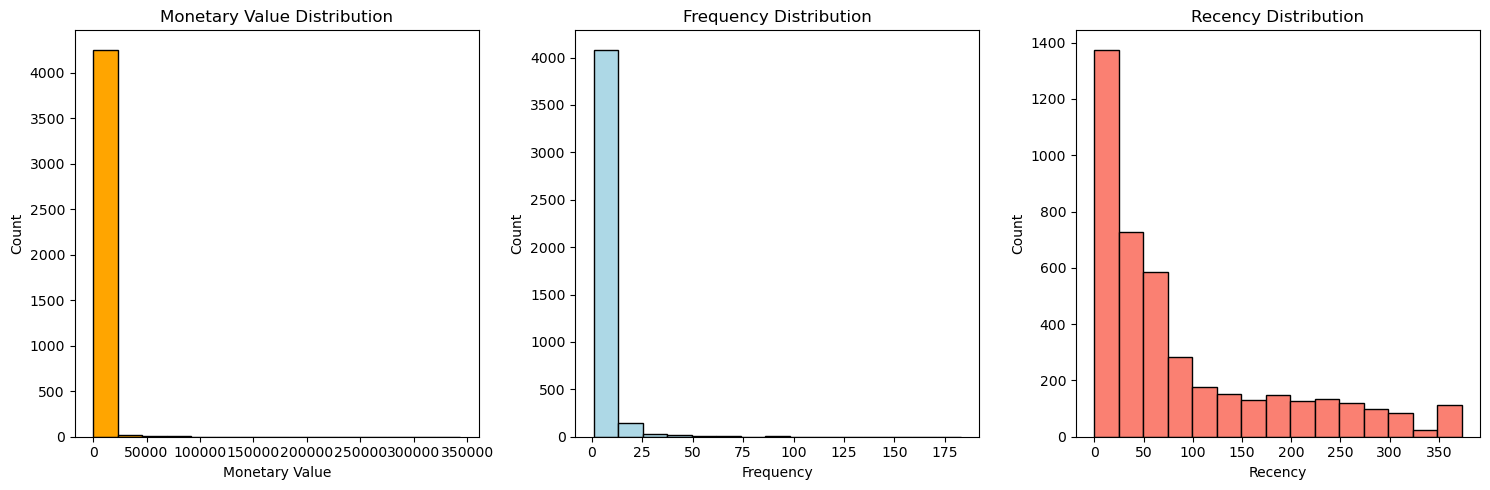

In [89]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(aggregated_df["MonetaryValue"], bins=15, color='orange',edgecolor='black' )
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
plt.hist(aggregated_df["Frequency"], bins=15, color='lightblue',edgecolor='black' )
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1,3,3)
plt.hist(aggregated_df["Recency"], bins=15, color='salmon',edgecolor='black' )
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

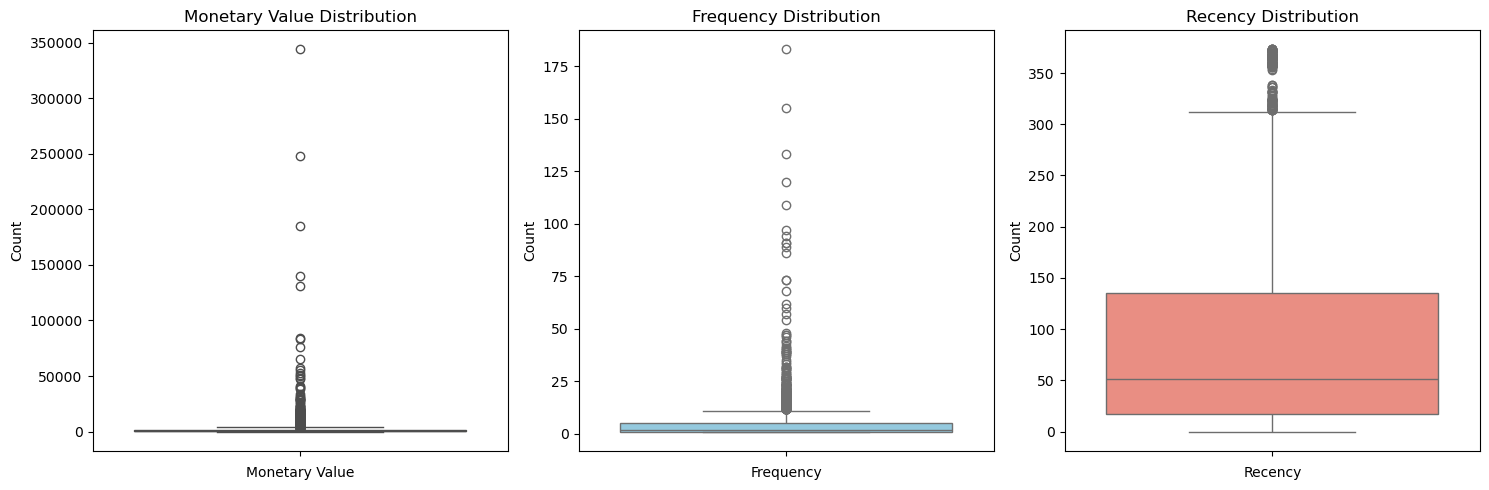

In [90]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data = aggregated_df["MonetaryValue"], color='orange')
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.boxplot(data = aggregated_df["Frequency"], color='skyblue')
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1,3,3)
sns.boxplot(data = aggregated_df["Recency"], color='salmon')
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [91]:
M_Q1 = aggregated_df['MonetaryValue'].quantile(0.25)
M_Q2 = aggregated_df['MonetaryValue'].quantile(0.75)
M_IQR = M_Q2 - M_Q1

monetary_outliers_df = aggregated_df[(aggregated_df['MonetaryValue'] > (M_Q2 + 1.5 * M_IQR)) | 
                        (aggregated_df['MonetaryValue'] < (M_Q1 - 1.5 * M_IQR))].copy()

monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,421.000000,421.000000,421.000000,421,421.000000
mean,15107.242280,12150.487568,17.225653,2010-11-09 16:56:38.764845568,29.847981
min,12357.000000,3796.930000,1.000000,2009-12-10 18:03:00,0.000000
25%,13615.000000,4590.530000,8.000000,2010-11-08 15:42:00,3.000000
50%,15005.000000,6191.320000,12.000000,2010-11-26 12:44:00,13.000000
75%,16700.000000,10164.490000,18.000000,2010-12-06 11:06:00,31.000000
max,18260.000000,343764.350000,183.000000,2010-12-09 19:32:00,364.000000
std,1731.684418,25632.405012,19.758275,NaN,51.563698


In [92]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q2 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q2 - F_Q1

frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q2 + 1.5 * F_IQR)) | 
                        (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()

frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.655914,14309.816724,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1088.440000,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4321.670000,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6590.060000,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.405000,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,343764.350000,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429987,31069.985754,21.932937,NaN,26.589117


In [93]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers_df.index))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3811.000000,3811.000000,3811.000000,3811,3811.000000
mean,15375.875098,884.438897,2.864602,2010-09-03 11:37:33.077932288,97.067699
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13912.500000,277.925000,1.000000,2010-07-08 16:27:00,22.000000
50%,15387.000000,587.690000,2.000000,2010-10-12 16:25:00,58.000000
75%,16851.000000,1269.070000,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3788.210000,11.000000,2010-12-09 20:01:00,373.000000
std,1692.963969,816.814742,2.244160,NaN,98.089381


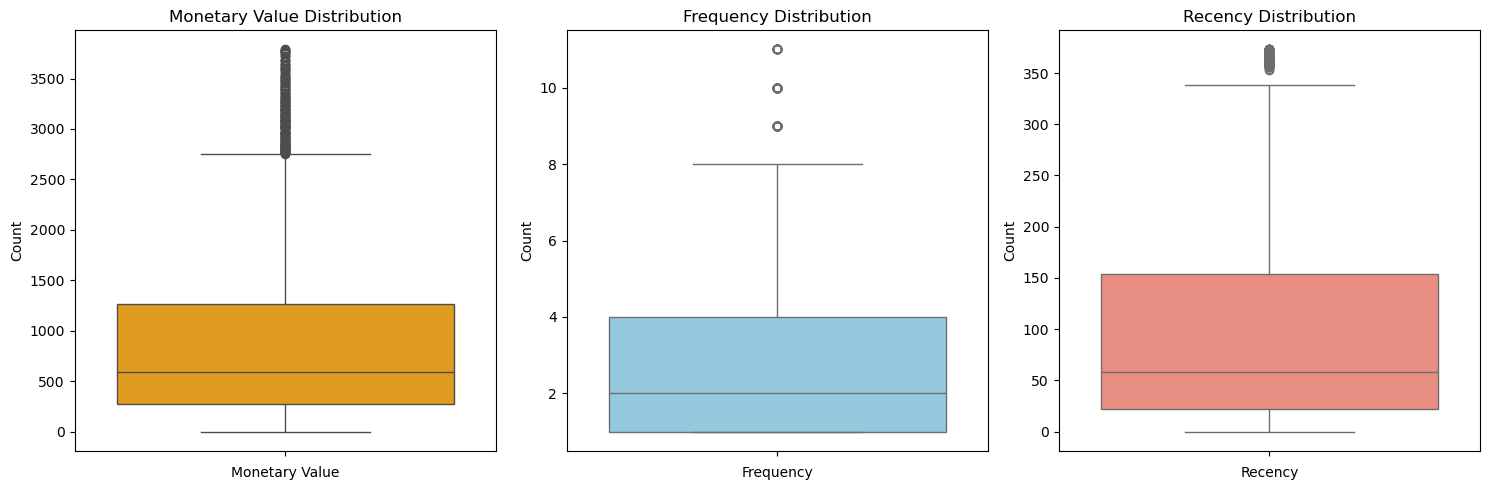

In [94]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data = non_outliers_df["MonetaryValue"], color='orange')
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.boxplot(data = non_outliers_df["Frequency"], color='skyblue')
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1,3,3)
sns.boxplot(data = non_outliers_df["Recency"], color='salmon')
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

<Figure size 1500x1500 with 0 Axes>

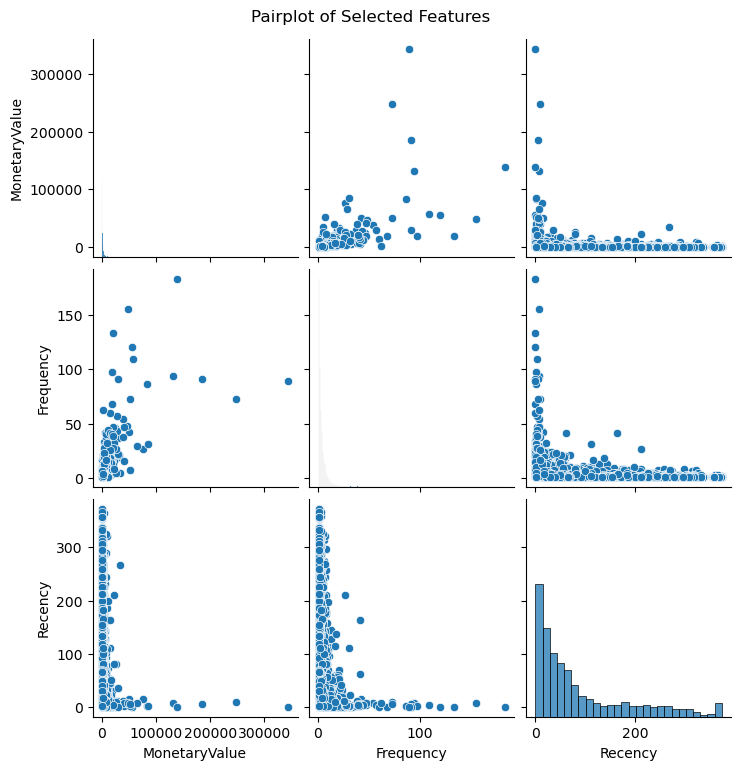

In [95]:
plt.figure(figsize=(15,15))
sns.pairplot(aggregated_df[["MonetaryValue","Frequency","Recency"]])

plt.suptitle("Pairplot of Selected Features", y=1.02) 
plt.show() 

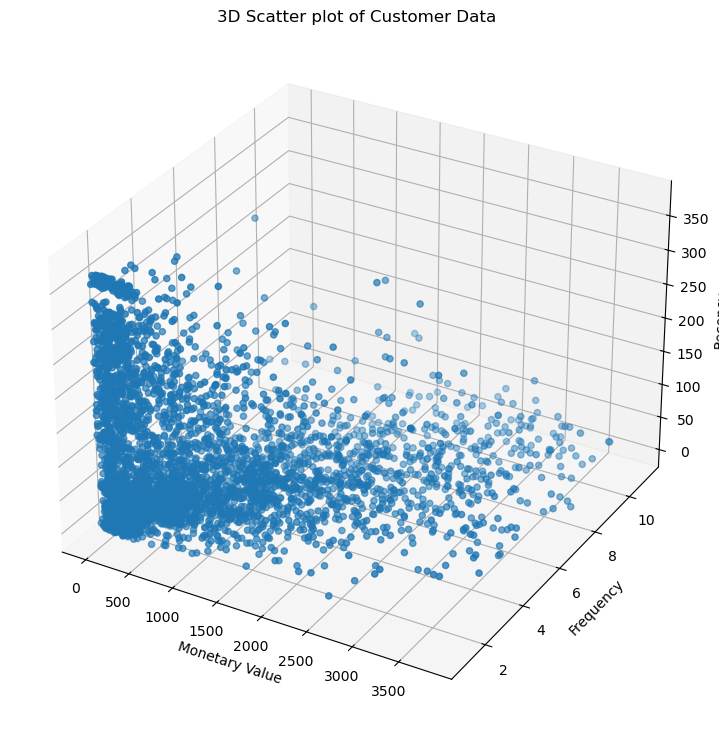

In [96]:
fig = plt.figure(figsize=(10,9))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(non_outliers_df['MonetaryValue'],non_outliers_df['Frequency'],non_outliers_df['Recency'])

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

ax.set_title("3D Scatter plot of Customer Data")
plt.show()


In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers_df[['MonetaryValue','Frequency','Recency']])
scaled_data

array([[-0.88284831, -0.38531824,  0.68244986],
       [ 0.53737852, -0.38531824, -0.96932179],
       [-0.81213757, -0.83097766, -0.24539718],
       ...,
       [-0.62132263, -0.83097766,  2.01814175],
       [ 0.44323221, -0.38531824,  0.14205543],
       [ 1.72800052,  0.50600061, -0.81637997]])

In [98]:
scaled_data = pd.DataFrame(scaled_data, index = non_outliers_df.index, columns=["MonetaryValue","Frequency","Recency"])
scaled_data

,MonetaryValue,Frequency,Recency
0,-0.882848,-0.385318,0.682450
1,0.537379,-0.385318,-0.969322
2,-0.812138,-0.830978,-0.245397
3,1.636695,-0.385318,-0.561477
4,-0.714465,-0.830978,-0.887753
...,...,...,...
4280,-0.297131,1.397319,-0.816380
4281,-0.578859,-0.830978,-0.316770
4282,-0.621323,-0.830978,2.018142
4283,0.443232,-0.385318,0.142055


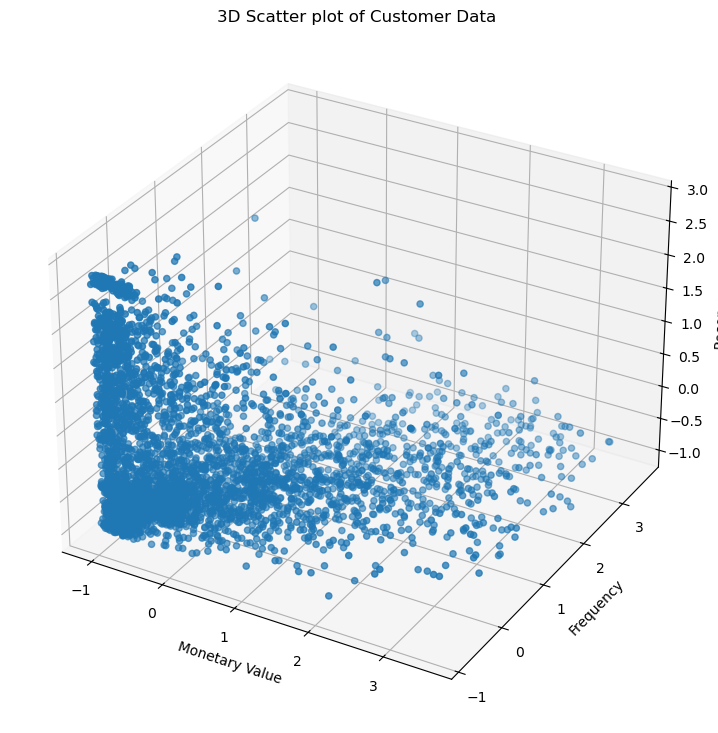

In [99]:
fig = plt.figure(figsize=(10,9))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(scaled_data['MonetaryValue'],scaled_data['Frequency'],scaled_data['Recency'])

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

ax.set_title("3D Scatter plot of Customer Data")
plt.show()


## KMeans Clustering

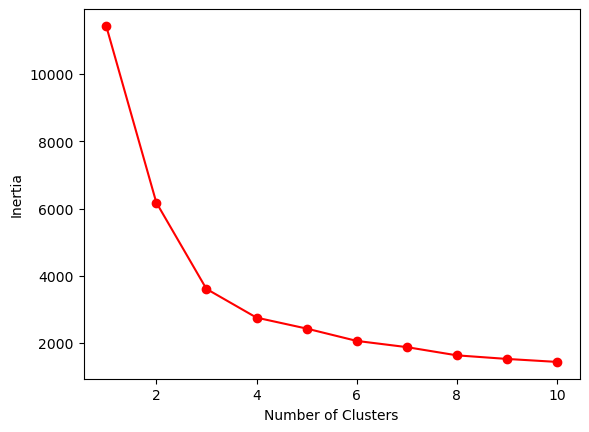

In [100]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

interia = []
for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    interia.append(model.inertia_)

plt.plot(range(1,11),interia,marker='o',color='red')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

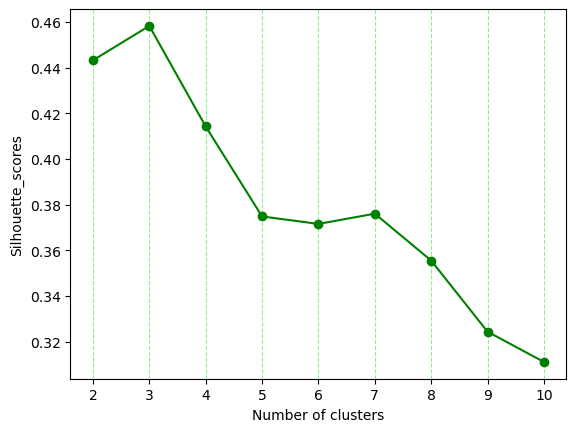

In [101]:
silhouette_scores = []
for i in range(2,11):
    model = KMeans(n_clusters=i,random_state=42)
    model.fit(scaled_data)
    score = silhouette_score(scaled_data, labels=model.labels_)
    silhouette_scores.append(score)

plt.plot(range(2,11),silhouette_scores,marker='o',color='green')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette_scores")
plt.grid(axis='x',linestyle='--', color='lightgreen')
plt.show()

In [102]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4, random_state=42)
model.fit(scaled_data)

KMeans(n_clusters=4, random_state=42)

In [103]:
cluster_labels = model.fit_predict(scaled_data[['MonetaryValue','Frequency','Recency']])
cluster_labels

array([0, 1, 3, ..., 0, 1, 1])

In [104]:
non_outliers_df["Cluster"] = cluster_labels
non_outliers_df.head(20)

C:\Users\moham\AppData\Local\Temp\ipykernel_29388\2650695083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df["Cluster"] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,163.41,2,2010-06-28 13:53:00,164,0
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,1
2,12348.0,221.16,1,2010-09-27 14:59:00,73,3
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1
4,12351.0,300.93,1,2010-11-29 15:23:00,10,3
5,12352.0,343.80,2,2010-11-29 10:07:00,10,3
6,12353.0,317.76,1,2010-10-27 12:44:00,43,3
7,12355.0,488.21,1,2010-05-21 11:59:00,202,0
8,12356.0,3126.25,3,2010-11-24 12:24:00,15,2
10,12358.0,2150.61,3,2010-11-29 10:56:00,10,1


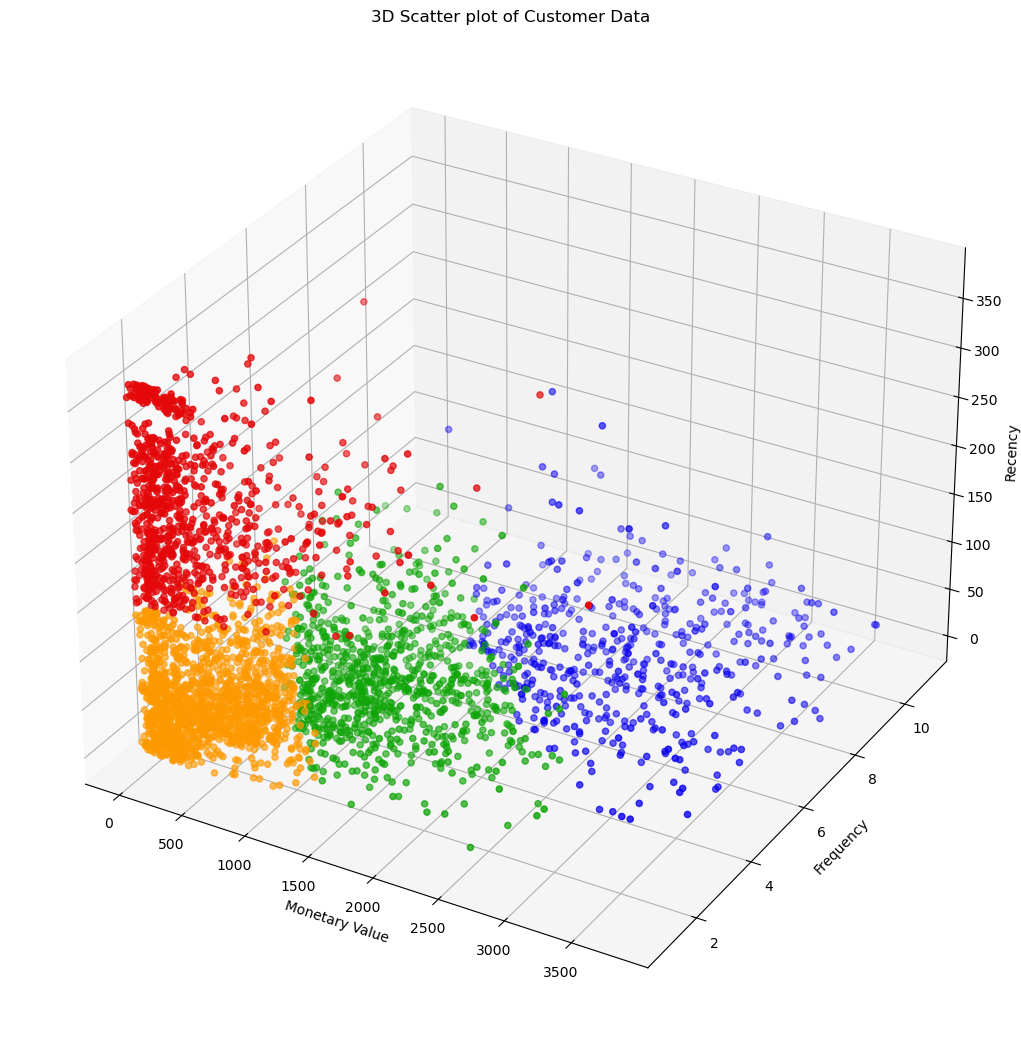

In [105]:
clustered_colors = {
    0:'#E4080A', #red
    1:'#10A509', #green
    2:'#0901EF', #blue
    3:'#FE9900' #orange
}

colors = non_outliers_df["Cluster"].map(clustered_colors)

fig = plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['Frequency'],
                     non_outliers_df['Recency'],
                     c=colors,
                     marker='o')

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

ax.set_title("3D Scatter plot of Customer Data")
plt.show()

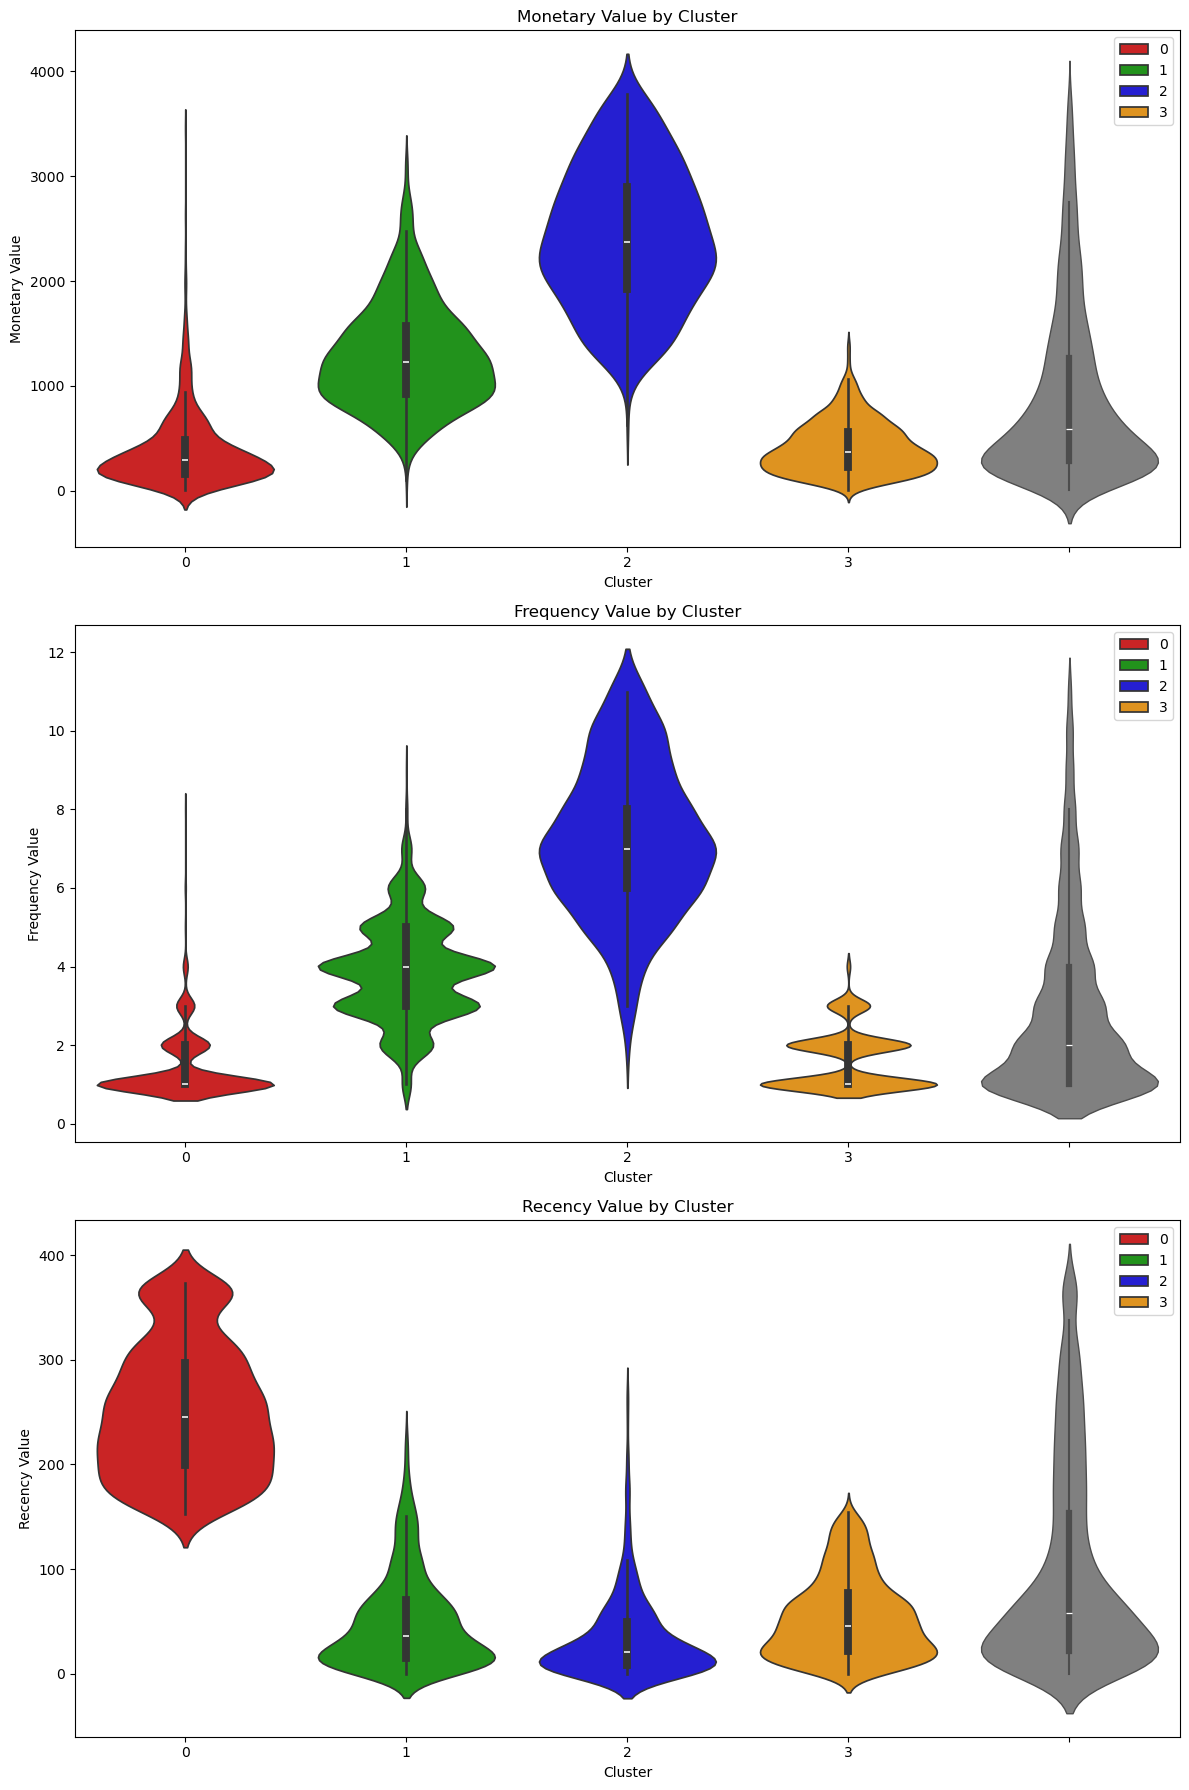

In [112]:
plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=non_outliers_df['Cluster'],y=non_outliers_df['MonetaryValue'], palette=clustered_colors, hue=non_outliers_df['Cluster'])
sns.violinplot(y=non_outliers_df["MonetaryValue"], color='grey',linewidth=1)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3,1,2)
sns.violinplot(x=non_outliers_df['Cluster'],y=non_outliers_df['Frequency'], palette=clustered_colors, hue=non_outliers_df['Cluster'])
sns.violinplot(y=non_outliers_df["Frequency"], color='grey',linewidth=1)
plt.title('Frequency Value by Cluster')
plt.ylabel('Frequency Value')

plt.subplot(3,1,3)
sns.violinplot(x=non_outliers_df['Cluster'],y=non_outliers_df['Recency'], palette=clustered_colors, hue=non_outliers_df['Cluster'])
sns.violinplot(y=non_outliers_df["Recency"], color='grey',linewidth=1)
plt.title('Recency Value by Cluster')
plt.ylabel('Recency Value')

plt.tight_layout()
plt.show()

In [116]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers,frequency_only_outliers,monetary_and_frequency_outliers])
outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.0,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.0,7409.21,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


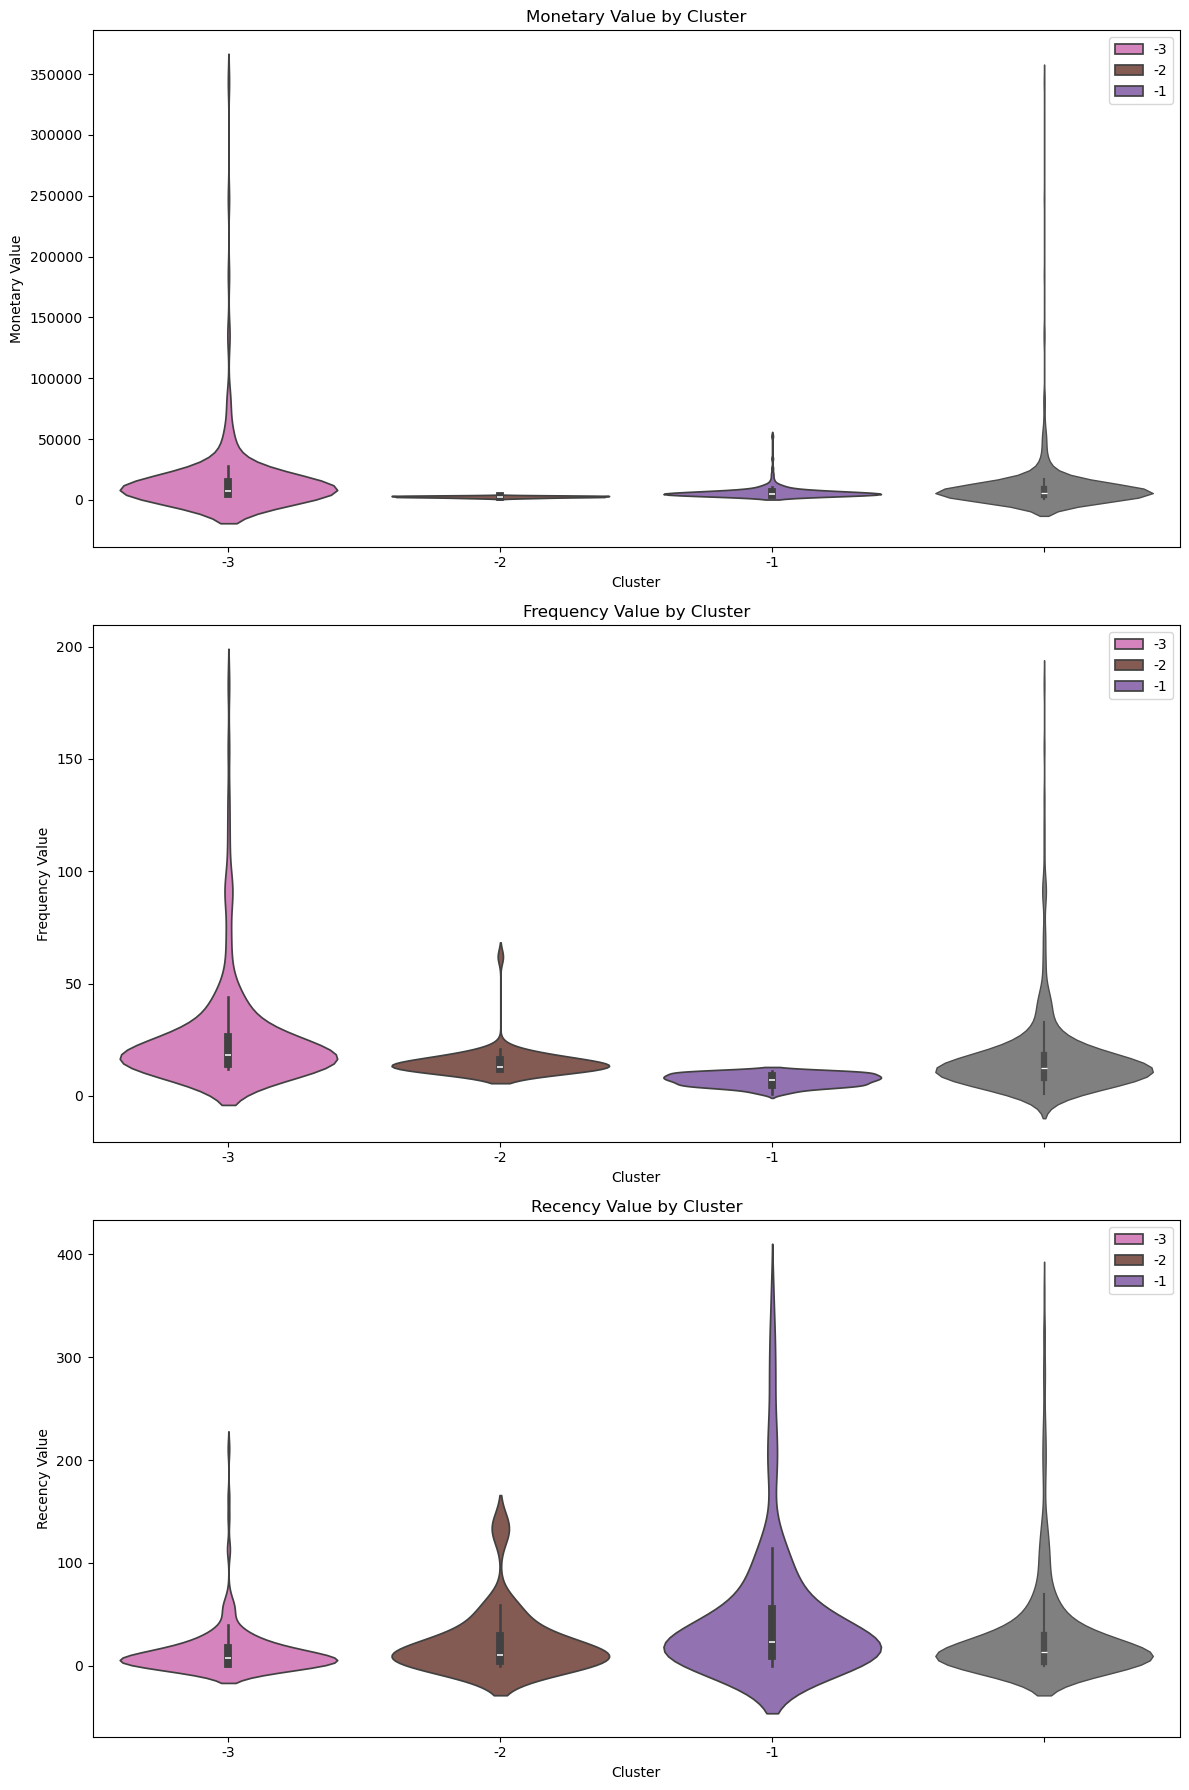

In [121]:
cluster_colors = {
    -1:'#9467bd',
    -2:'#8c564b',
    -3:'#e377c2' 
}

colors = non_outliers_df["Cluster"].map(cluster_colors)

plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=outlier_clusters_df['Cluster'],y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df["MonetaryValue"], color='grey',linewidth=1)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3,1,2)
sns.violinplot(x=outlier_clusters_df['Cluster'],y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df["Frequency"], color='grey',linewidth=1)
plt.title('Frequency Value by Cluster')
plt.ylabel('Frequency Value')

plt.subplot(3,1,3)
sns.violinplot(x=outlier_clusters_df['Cluster'],y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df["Recency"], color='grey',linewidth=1)
plt.title('Recency Value by Cluster')
plt.ylabel('Recency Value')

plt.tight_layout()
plt.show()


In [123]:
cluster_labels = {
    0:"RE-ENGAGE",
    1:"RETAIN",
    2:"REWARD",
    3:"NURTURE",
    -1:"PAMPER",
    -2:"UPSELL",
    -3:"DELIGHT"
}

In [127]:
full_clustering_df = pd.concat([non_outliers_df,outlier_clusters_df])
full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,163.41,2,2010-06-28 13:53:00,164,0
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,1
2,12348.0,221.16,1,2010-09-27 14:59:00,73,3
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1
4,12351.0,300.93,1,2010-11-29 15:23:00,10,3
...,...,...,...,...,...,...
4235,18223.0,7409.21,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


In [129]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)
full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.0,163.41,2,2010-06-28 13:53:00,164,0,RE-ENGAGE
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,1,RETAIN
2,12348.0,221.16,1,2010-09-27 14:59:00,73,3,NURTURE
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1,RETAIN
4,12351.0,300.93,1,2010-11-29 15:23:00,10,3,NURTURE
...,...,...,...,...,...,...,...
4235,18223.0,7409.21,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3,DELIGHT


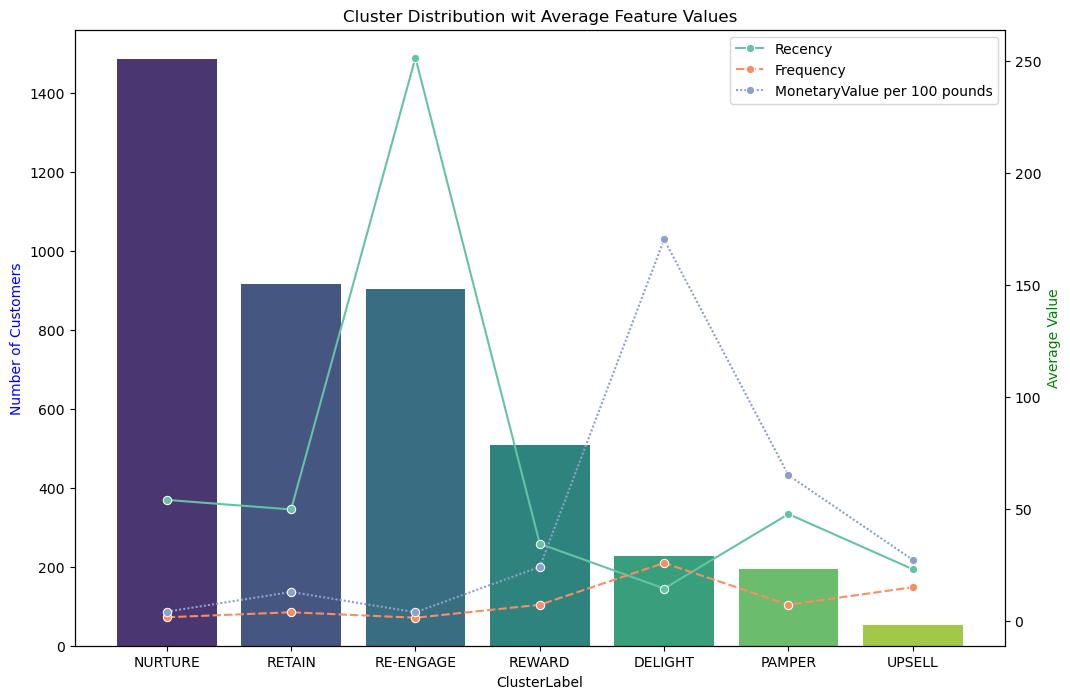

In [141]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"]/100
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency','Frequency','MonetaryValue per 100 pounds']].mean()

fig,ax1 = plt.subplots(figsize=(12,8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values,ax=ax1,palette='viridis',hue=cluster_counts.index)
ax1.set_ylabel("Number of Customers",color='b')
ax1.set_title("Cluster Distribution wit Average Feature Values")

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel("Average Value", color='g')

plt.show()